# Fraud Detection Analysis using Machine Learning


## Project Overview
This project analyzes financial transaction data to identify fraudulent transactions using machine learning techniques. The workflow includes data cleaning, exploratory data analysis, feature engineering, model training, evaluation, and feature importance analysis.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading the dataset 
df = pd.read_csv("Fraud.csv")

In [3]:
df = df.sample(50000, random_state=42)

In [4]:
#Dataset overview
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [5]:
df.shape

(50000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 3737323 to 409882
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            50000 non-null  int64  
 1   type            50000 non-null  object 
 2   amount          50000 non-null  float64
 3   nameOrig        50000 non-null  object 
 4   oldbalanceOrg   50000 non-null  float64
 5   newbalanceOrig  50000 non-null  float64
 6   nameDest        50000 non-null  object 
 7   oldbalanceDest  50000 non-null  float64
 8   newbalanceDest  50000 non-null  float64
 9   isFraud         50000 non-null  int64  
 10  isFlaggedFraud  50000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 4.6+ MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,50000.000000
mean,243.524580,1.802593e+05,8.405440e+05,8.623184e+05,1.092142e+06,1.217457e+06,0.001400,0.000020
std,142.989564,5.394901e+05,2.905490e+06,2.940672e+06,3.123411e+06,3.349252e+06,0.037391,0.004472
min,1.000000,9.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,155.000000,1.358008e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,239.000000,7.568036e+04,1.384450e+04,0.000000e+00,1.432386e+05,2.210873e+05,0.000000,0.000000
75%,335.000000,2.092434e+05,1.070732e+05,1.471921e+05,9.639589e+05,1.129805e+06,0.000000,0.000000
max,736.000000,3.697390e+07,3.359321e+07,3.374855e+07,1.540135e+08,1.542411e+08,1.000000,1.000000


In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [9]:
#Missing value analysis
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df['isFraud'].value_counts()

isFraud
0    49930
1       70
Name: count, dtype: int64

<Axes: xlabel='isFraud', ylabel='count'>

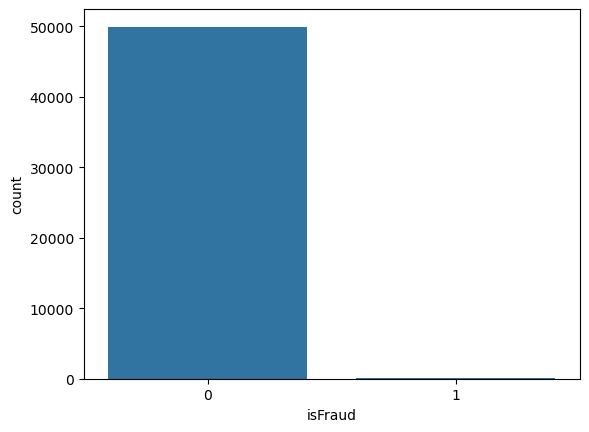

In [11]:
#Fraud class distribution
sns.countplot(x='isFraud', data=df)

<Axes: xlabel='type', ylabel='count'>

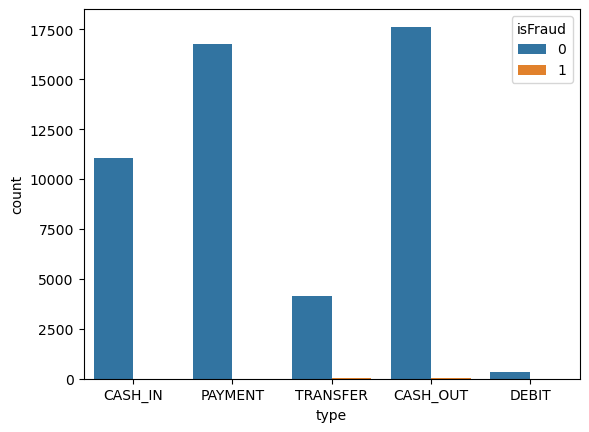

In [12]:
#Transaction type analysis
sns.countplot(x='type', hue='isFraud', data=df)

<Axes: xlabel='isFraud', ylabel='amount'>

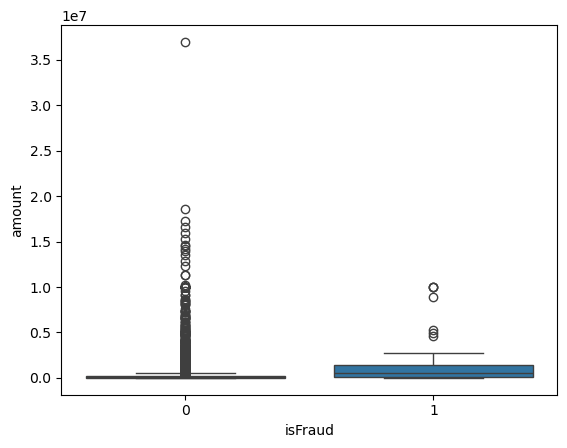

In [13]:
#Transaction Amount distribution
sns.boxplot(x='isFraud', y='amount', data=df)

<Axes: xlabel='amount'>

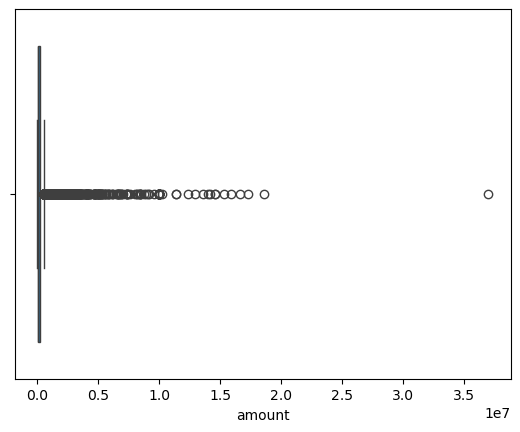

In [14]:
#Outlier detection
sns.boxplot(x=df['amount'])

In [15]:
#Feature Engineering
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [16]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

In [17]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

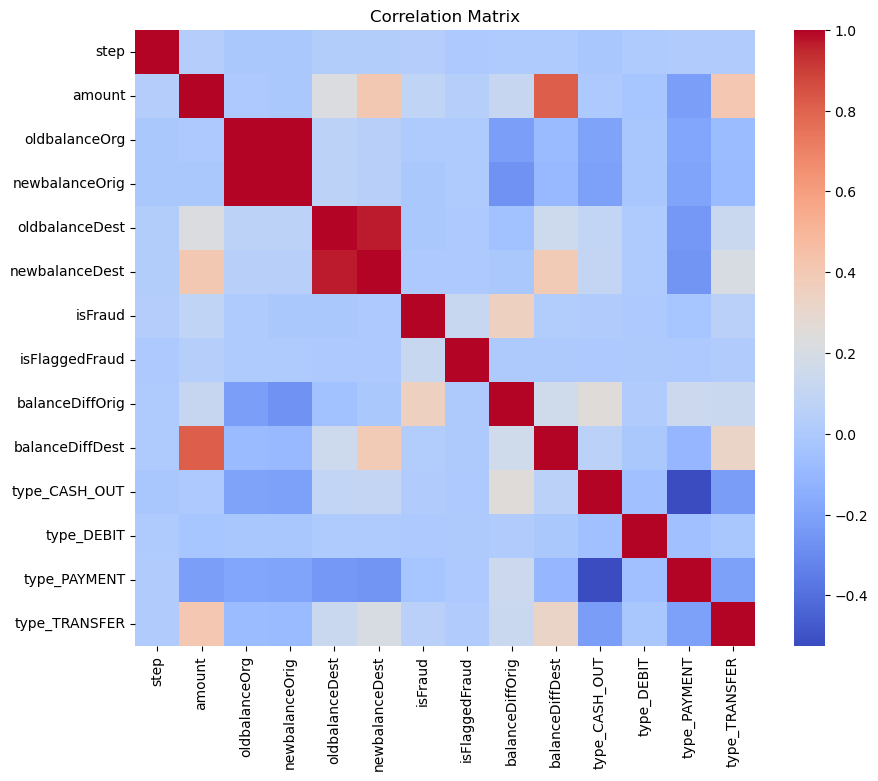

In [18]:
#Correlation analysis
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
#Train-Test split
from sklearn.model_selection import train_test_split
X = df.drop('isFraud', axis=1)
y = df['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
#Model development
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [21]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[9985    0]
 [   5   10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9985
           1       1.00      0.67      0.80        15

    accuracy                           1.00     10000
   macro avg       1.00      0.83      0.90     10000
weighted avg       1.00      1.00      1.00     10000



In [22]:
#Feature importance analysis
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

balanceDiffOrig    0.369876
oldbalanceOrg      0.153989
amount             0.107676
balanceDiffDest    0.074053
newbalanceOrig     0.072283
step               0.054474
type_TRANSFER      0.049982
newbalanceDest     0.033815
type_PAYMENT       0.031165
oldbalanceDest     0.026385
dtype: float64